# Classical Mpemba effect in a three-level Markov system

The **Mpemba effect** is the counter-intuitive observation that a system that
starts *farther* from equilibrium (hotter) can reach equilibrium *faster* than
one that starts closer (colder).

Here we simulate the **classical** (population-level) Mpemba effect in a
three-level system whose populations obey the Markov master equation

$$\frac{dP}{dt} = W P, \qquad P=(P_0,P_1,P_2)^T,$$

where the generator $W$ (columns sum to zero) satisfies **detailed balance**, so
its steady state is the Gibbs distribution at the bath temperature $T_b$.

**Why it happens** (Lu & Raz 2017): diagonalising $W$ gives relaxation modes
$P(t)=P_\mathrm{eq}+a_2\,e^{\lambda_2 t}v_2+a_3\,e^{\lambda_3 t}v_3$ with
$\lambda_3<\lambda_2<0$. The *slowest* mode $\lambda_2$ controls the long-time
tail. A state whose projection onto this mode vanishes, $a_2(T)=0$, relaxes
purely through the fast mode and cools much faster. There is a **strong-Mpemba
temperature** $T^*$ where $a_2(T^*)=0$: a system prepared at $T^*$, although
hotter, has zero slow-mode content.

**Key point**: strong Mpemba requires the direct $0\leftrightarrow 2$ transition.
A nearest-neighbour-only *ladder* (0&ndash;1&ndash;2) cannot produce it. Below we
**search** for a model with a strong root, then verify the crossing by direct
time evolution.

In [24]:
# ================= model =================
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import brentq
from time import perf_counter

E0, E1 = 0.0, 1.0   # lowest two levels fixed; E2 is scanned
G10 = 1.0           # sets the unit of time


def thermal_populations(T, E):
    # Gibbs populations P_i(T) = exp(-E_i/T)/Z, vectorized over T
    T = np.atleast_1d(np.asarray(T, float)); E = np.asarray(E, float)
    x = -E[None, :] / T[:, None]; x -= x.max(1, keepdims=True)
    w = np.exp(x); return w / w.sum(1, keepdims=True)


def build_generator(E2, r1, r2, Tb):
    # full 3-level generator (0-1, 1-2, 0-2); detailed balance -> Gibbs steady state
    E = np.array([E0, E1, E2]); G21, G20 = r1 * G10, r2 * G10; b = 1.0 / Tb
    G01 = G10 * np.exp(-b * (E1 - E0)); G12 = G21 * np.exp(-b * (E2 - E1)); G02 = G20 * np.exp(-b * (E2 - E0))
    W = np.array([[-G01 - G02, G10, G20],
                  [G01, -G10 - G12, G21],
                  [G02, G12, -G20 - G21]])
    return W, E, dict(G10=G10, G01=G01, G21=G21, G12=G12, G20=G20, G02=G02)


def diagonalize(W):
    # eigenvalues lambda1=0, lambda2 (slow), lambda3 (fast), with eigenvectors
    vals, V = np.linalg.eig(W)
    if np.max(np.abs(vals.imag)) > 1e-8: return None
    o = np.argsort(vals.real)[::-1]; vals, V = vals[o].real, V[:, o].real
    if V[:, 0].sum() < 0: V[:, 0] *= -1
    V[:, 0] /= V[:, 0].sum()
    return vals, V, np.linalg.inv(V)


def a2_of_T(T, E, Vinv):  # slow-mode amplitude a2(T) = (V^-1 P(T))_1
    return (thermal_populations(T, E) @ Vinv.T)[:, 1]


def evolve(P0, t, vals, V, Vinv):  # P(t) = V diag(e^{lambda t}) V^-1 P0
    a = Vinv @ P0
    return (np.exp(t[:, None] * vals[None, :]) * a[None, :]) @ V.T


def trace_dist(P, Peq):  # D = 1/2 sum_i |P_i - Peq_i| (trace distance, diagonal)
    return 0.5 * np.sum(np.abs(P - Peq[None, :]), axis=1)


In [25]:
# ================= search for a strong-Mpemba model =================
# a model is "strong" if a2(T*) = 0 for some T* > Tb (a hotter state with zero
# slow-mode content). We scan E2, r1=G21/G10, r2=G20/G10 and Tb.
t0 = perf_counter()
E2_grid = np.linspace(1.2, 5.5, 15)
r1_grid = np.logspace(-2, 1.0, 12)   # G21 / G10
r2_grid = np.logspace(-1, 1.0, 12)   # G20 / G10
Tb_grid = np.linspace(0.4, 2.4, 8)

hits = []
for E2 in E2_grid:
    for r1 in r1_grid:
        for r2 in r2_grid:
            for Tb in Tb_grid:
                W, E, rates = build_generator(E2, r1, r2, Tb)
                d = diagonalize(W)
                if d is None: continue
                vals, V, Vinv = d
                T = np.logspace(np.log10(Tb * 1.001), np.log10(Tb * 40), 250)
                a2 = a2_of_T(T, E, Vinv)
                for i in range(len(T) - 1):
                    if a2[i] * a2[i + 1] < 0 and T[i] > 1.01 * Tb:  # strong root T*
                        root = brentq(lambda tt: a2_of_T(np.array([tt]), E, Vinv)[0], T[i], T[i + 1])
                        m = (T > 1.01 * Tb) & (T < root)
                        hits.append(dict(amax=float(np.abs(a2[m]).max()),   # cold slow-mode size
                                         sep=float(abs(vals[2]) / abs(vals[1])),
                                         E2=E2, r1=r1, r2=r2, Tb=Tb, root=root,
                                         l2=vals[1], l3=vals[2]))
                        break

print("strong-Mpemba models found:", len(hits), f"({perf_counter()-t0:.1f}s)")
# keep models with a clear separation of time scales, then take the one with the
# largest slow-mode amplitude -> the most visible crossing
good = [h for h in hits if h["sep"] > 2.5]
good.sort(key=lambda h: -h["amax"])
best = good[0]
print("chosen:", {k: round(float(v), 4) for k, v in best.items()
                  if k in ("E2", "r1", "r2", "Tb", "root", "sep")})


strong-Mpemba models found: 1661 (3.1s)
chosen: {'sep': 3.1132, 'E2': 5.5, 'r1': 0.1233, 'r2': 4.3288, 'Tb': 1.2571, 'root': 49.9315}


In [27]:
# ================= reconstruct + verify the chosen model =================
E2, r1, r2, Tb = best["E2"], best["r1"], best["r2"], best["Tb"]
W, E, rates = build_generator(E2, r1, r2, Tb)
vals, V, Vinv = diagonalize(W)
Peq = thermal_populations([Tb], E)[0]

# cold state = temperature with the largest slow-mode amplitude; hot state = strong root
Tscan = np.linspace(Tb * 1.001, 60, 4000)
a2 = a2_of_T(Tscan, E, Vinv)
Th = best["root"]
m = (Tscan > 1.01 * Tb) & (Tscan < Th)
Tc = Tscan[m][np.abs(a2[m]).argmax()]

D0h = trace_dist(thermal_populations([Th], E), Peq)[0]
D0c = trace_dist(thermal_populations([Tc], E), Peq)[0]
assert D0h > D0c, "hot must start farther from equilibrium"

# full time evolution + crossing time
tau_slow = 1.0 / abs(vals[1])
t = np.linspace(0, 6 * tau_slow, 6000)
Ph = evolve(thermal_populations([Th], E)[0], t, vals, V, Vinv)
Pc = evolve(thermal_populations([Tc], E)[0], t, vals, V, Vinv)
Dh, Dc = trace_dist(Ph, Peq), trace_dist(Pc, Peq)
diff = Dh - Dc
ic = np.where((diff[:-1] > 0) & (diff[1:] <= 0))[0][0]
t_cross = t[ic]

print(f"E2={E2:.4f}   T_bath={Tb:.4f}   T_cold={Tc:.4f}   T_hot=T*={Th:.4f}")
print("rates:", {k: round(float(v), 4) for k, v in rates.items()})
print("eigenvalues =", np.round(vals, 5))
print(f"D_hot(0)={D0h:.4f}  >  D_cold(0)={D0c:.4f};   |a2(T_hot)|={abs(a2_of_T(np.array([Th]), E, Vinv)[0]):.2e} ~ 0")
print(f"crossing time t_cross = {t_cross:.4f}  ({t_cross/tau_slow:.2f} tau_slow),  D at crossing = {Dh[ic]:.4f}")


E2=5.5000   T_bath=1.2571   T_cold=3.1239   T_hot=T*=49.9315
rates: {'G10': 1.0, 'G01': 0.4514, 'G21': 0.1233, 'G12': 0.0034, 'G20': 4.3288, 'G02': 0.0545}
eigenvalues = [ 0.      -1.44934 -4.51202]
D_hot(0)=0.3354  >  D_cold(0)=0.1562;   |a2(T_hot)|=5.82e-17 ~ 0
crossing time t_cross = 0.4348  (0.63 tau_slow),  D at crossing = 0.0472


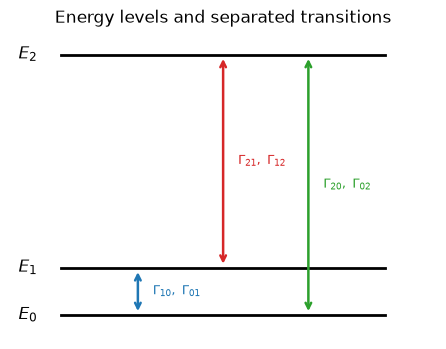

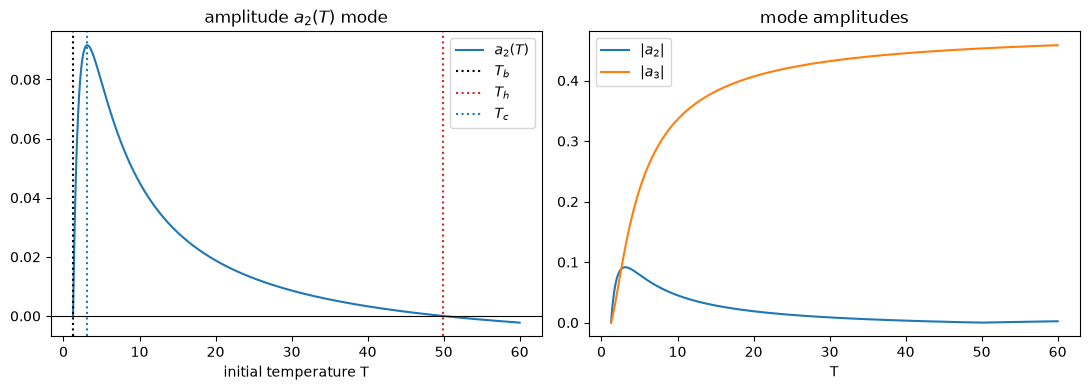

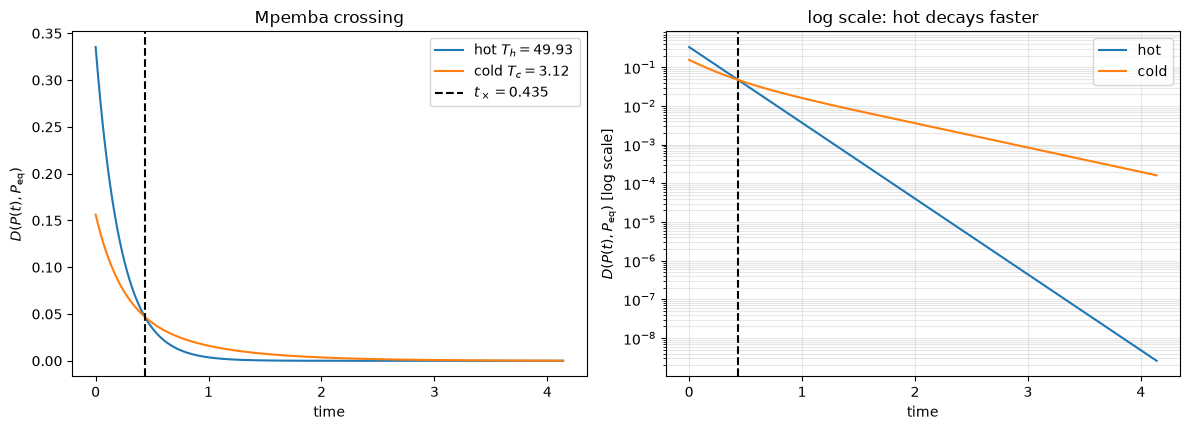

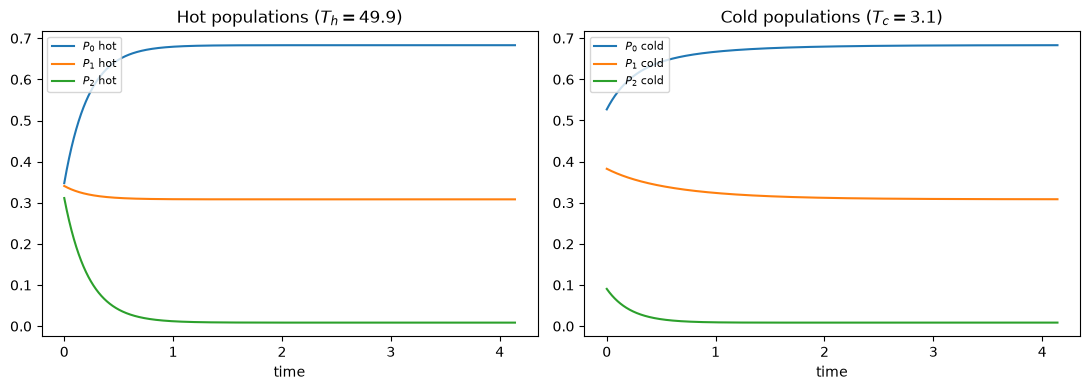

In [55]:
# ================= plots =================
a3 = (thermal_populations(Tscan, E) @ Vinv.T)[:, 2]
D0 = trace_dist(thermal_populations(Tscan, E), Peq)

# 1. energy-level diagram with horizontally separated transition rates
fig, ax = plt.subplots(figsize=(5.5, 4))
for Ei, lab in zip(E, ["$E_0$", "$E_1$", "$E_2$"]):
    ax.plot([0.12, 0.88], [Ei, Ei], "k-", lw=2)
    ax.text(0.02, Ei, lab, va="center", fontsize=12)

transitions = [
    (E0, E1, 0.30, r"$\Gamma_{10},\ \Gamma_{01}$", "tab:blue"),
    (E1, E2, 0.50, r"$\Gamma_{21},\ \Gamma_{12}$", "tab:red"),
    (E0, E2, 0.70, r"$\Gamma_{20},\ \Gamma_{02}$", "tab:green"),
]

for lower, upper, x_position, label, color in transitions:
    ax.annotate(
        "",
        xy=(x_position, upper),
        xytext=(x_position, lower),
        arrowprops=dict(
            arrowstyle="<->",
            color=color,
            lw=1.8,
            shrinkA=3,
            shrinkB=3,
        ),
    )
    ax.text(
        x_position + 0.035,
        (lower + upper) / 2,
        label,
        color=color,
        fontsize=9,
        va="center",
    )

ax.set_xlim(0, 1)
ax.set_ylim(-0.5, E2 + 0.5)
ax.axis("off")
ax.set_title("Energy levels and separated transitions")

# 2. slow-mode amplitude a2(T) and mode amplitudes |a2|, |a3|
fig, ax = plt.subplots(1, 2, figsize=(11, 4))
ax[0].plot(Tscan, a2, label="$a_2(T)$")
ax[0].axhline(0, c="k", lw=0.8)
ax[0].axvline(Tb, ls=":", label="$T_b$", color="black")
ax[0].axvline(Th, ls=":", label="$T_h$", color="tab:red")
ax[0].axvline(Tc, ls=":", label="$T_c$", color="tab:blue")
ax[0].set_xlabel("initial temperature T")
ax[0].set_title("amplitude $a_2(T)$ mode")
ax[0].legend()
ax[1].plot(Tscan, np.abs(a2), label="$|a_2|$")
ax[1].plot(Tscan, np.abs(a3), label="$|a_3|$")
ax[1].set_xlabel("T")
ax[1].set_title("mode amplitudes")
ax[1].legend()
fig.tight_layout()
plt.show()

# 3. Mpemba crossing: linear scale and logarithmic y-axis
fig, ax = plt.subplots(1, 2, figsize=(12, 4.4))
ax[0].plot(t, Dh, label=f"hot $T_h={Th:.2f}$")
ax[0].plot(t, Dc, label=f"cold $T_c={Tc:.2f}$")
ax[0].axvline(
    t_cross,
    ls="--",
    c="k",
    label=f"$t_\\times={t_cross:.3f}$",
)
ax[0].set_xlabel("time")
ax[0].set_ylabel("$D(P(t),P_{\\rm eq})$")
ax[0].set_title("Mpemba crossing")
ax[0].legend()

Dh_log = np.maximum(np.asarray(Dh, dtype=float), np.finfo(float).tiny)
Dc_log = np.maximum(np.asarray(Dc, dtype=float), np.finfo(float).tiny)
ax[1].plot(t, Dh_log, label="hot")
ax[1].plot(t, Dc_log, label="cold")
ax[1].set_yscale("log")
ax[1].axvline(t_cross, ls="--", c="k")
ax[1].set_xlabel("time")
ax[1].set_ylabel("$D(P(t),P_{\\rm eq})$ [log scale]")
ax[1].set_title("log scale: hot decays faster")
ax[1].grid(True, which="both", alpha=0.3)
ax[1].legend()
fig.tight_layout()
plt.show()

# 4. populations P0,P1,P2 of the hot and cold states
fig, ax = plt.subplots(1, 2, figsize=(11, 4))
for j, lab in enumerate(["$P_0$", "$P_1$", "$P_2$"]):
    ax[0].plot(t, Ph[:, j], label=lab + " hot")
    ax[1].plot(t, Pc[:, j], label=lab + " cold")
ax[0].set_title(f"Hot populations ($T_h={Th:.1f}$)")
ax[1].set_title(f"Cold populations ($T_c={Tc:.1f}$)")
for current_ax in ax:
    current_ax.set_xlabel("time")
    current_ax.legend(fontsize=8)
fig.tight_layout()
plt.show()


HOT integration successful : True
COLD integration successful: True
max hot normalization error  = 4.440892098500626e-16
max cold normalization error = 4.440892098500626e-16
minimum hot population       = 0.008598670660230281
minimum cold population      = 0.008543026255519209
D_hot(0)  = 0.3353560508778483
D_cold(0) = 0.1562085459656895
Direct ODE crossing time = 0.43503062880119714


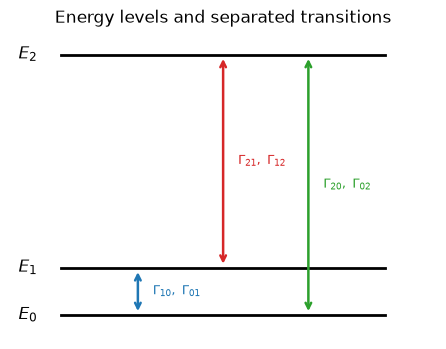

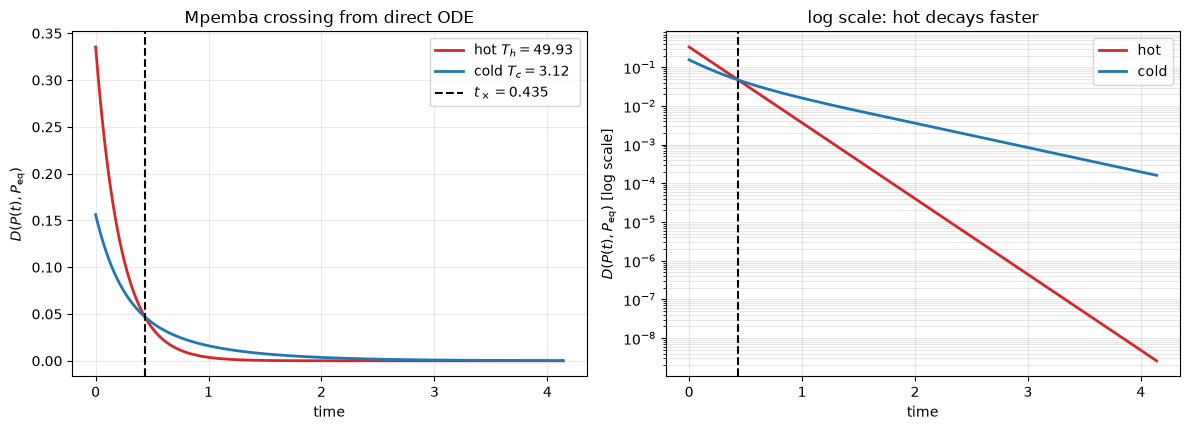

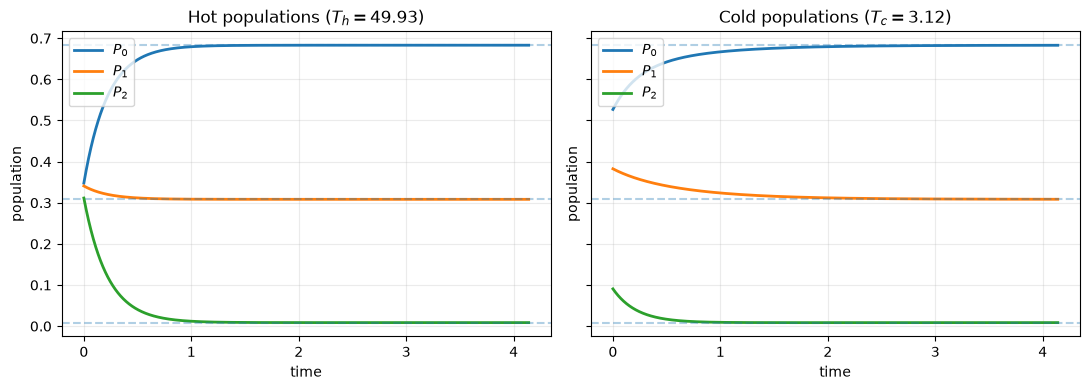

In [56]:
# ============================================================
# FIRST-PRINCIPLES DYNAMICAL VERIFICATION
# ============================================================
# Directly integrate dP/dt = W P with solve_ivp.
# This cell does not use eigenvalues or eigenvectors for propagation.

from scipy.integrate import solve_ivp


def master_equation(time, population, generator):
    """Classical Markov master equation: dP/dt = W @ P."""
    return generator @ population


Ph0 = thermal_populations([Th], E)[0]
Pc0 = thermal_populations([Tc], E)[0]

sol_hot = solve_ivp(
    master_equation,
    (t[0], t[-1]),
    Ph0,
    t_eval=t,
    args=(W,),
    method="DOP853",
    rtol=1e-11,
    atol=1e-13,
)
sol_cold = solve_ivp(
    master_equation,
    (t[0], t[-1]),
    Pc0,
    t_eval=t,
    args=(W,),
    method="DOP853",
    rtol=1e-11,
    atol=1e-13,
)

P_hot_ivp = sol_hot.y.T
P_cold_ivp = sol_cold.y.T
D_hot_ivp = 0.5 * np.sum(np.abs(P_hot_ivp - Peq[None, :]), axis=1)
D_cold_ivp = 0.5 * np.sum(np.abs(P_cold_ivp - Peq[None, :]), axis=1)
difference = D_hot_ivp - D_cold_ivp
crossings = np.where(
    (difference[:-1] > 0) & (difference[1:] <= 0)
)[0]

t_cross_ivp = None
if len(crossings) > 0:
    crossing_index_ivp = crossings[0]
    t1, t2 = t[crossing_index_ivp:crossing_index_ivp + 2]
    f1, f2 = difference[crossing_index_ivp:crossing_index_ivp + 2]
    t_cross_ivp = t1 - f1 * (t2 - t1) / (f2 - f1)

print("HOT integration successful :", sol_hot.success)
print("COLD integration successful:", sol_cold.success)
print("max hot normalization error  =", np.max(np.abs(P_hot_ivp.sum(axis=1) - 1.0)))
print("max cold normalization error =", np.max(np.abs(P_cold_ivp.sum(axis=1) - 1.0)))
print("minimum hot population       =", P_hot_ivp.min())
print("minimum cold population      =", P_cold_ivp.min())
print("D_hot(0)  =", D_hot_ivp[0])
print("D_cold(0) =", D_cold_ivp[0])
print("Direct ODE crossing time =", t_cross_ivp)

assert sol_hot.success
assert sol_cold.success
assert D_hot_ivp[0] > D_cold_ivp[0]
assert t_cross_ivp is not None
assert np.any(difference[crossing_index_ivp + 1:] < 0)

# 1. Energy levels and horizontally separated transitions.
fig, ax = plt.subplots(figsize=(5.5, 4))
for energy, level_label in zip(E, ["$E_0$", "$E_1$", "$E_2$"]):
    ax.plot([0.12, 0.88], [energy, energy], "k-", lw=2)
    ax.text(0.02, energy, level_label, va="center", fontsize=12)

transitions = [
    (E0, E1, 0.30, r"$\Gamma_{10},\ \Gamma_{01}$", "tab:blue"),
    (E1, E2, 0.50, r"$\Gamma_{21},\ \Gamma_{12}$", "tab:red"),
    (E0, E2, 0.70, r"$\Gamma_{20},\ \Gamma_{02}$", "tab:green"),
]

for lower, upper, x_position, label, color in transitions:
    ax.annotate(
        "",
        xy=(x_position, upper),
        xytext=(x_position, lower),
        arrowprops=dict(
            arrowstyle="<->",
            color=color,
            lw=1.8,
            shrinkA=3,
            shrinkB=3,
        ),
    )
    ax.text(
        x_position + 0.035,
        (lower + upper) / 2,
        label,
        color=color,
        fontsize=9,
        va="center",
    )

ax.set_xlim(0, 1)
ax.set_ylim(-0.5, E2 + 0.5)
ax.axis("off")
ax.set_title("Energy levels and separated transitions")
plt.show()

# 2. Direct ODE Mpemba crossing: linear and logarithmic y-axis.
fig, ax = plt.subplots(1, 2, figsize=(12, 4.4))
ax[0].plot(t, D_hot_ivp, color="tab:red", lw=2, label=f"hot $T_h={Th:.2f}$")
ax[0].plot(t, D_cold_ivp, color="tab:blue", lw=2, label=f"cold $T_c={Tc:.2f}$")
ax[0].axvline(
    t_cross_ivp,
    ls="--",
    c="k",
    label=f"$t_\\times={t_cross_ivp:.3f}$",
)
ax[0].set_xlabel("time")
ax[0].set_ylabel("$D(P(t),P_{\\rm eq})$")
ax[0].set_title("Mpemba crossing from direct ODE")
ax[0].grid(alpha=0.25)
ax[0].legend()

D_hot_log = np.maximum(D_hot_ivp, np.finfo(float).tiny)
D_cold_log = np.maximum(D_cold_ivp, np.finfo(float).tiny)
ax[1].plot(t, D_hot_log, color="tab:red", lw=2, label="hot")
ax[1].plot(t, D_cold_log, color="tab:blue", lw=2, label="cold")
ax[1].set_yscale("log")
ax[1].axvline(t_cross_ivp, ls="--", c="k")
ax[1].set_xlabel("time")
ax[1].set_ylabel("$D(P(t),P_{\\rm eq})$ [log scale]")
ax[1].set_title("log scale: hot decays faster")
ax[1].grid(True, which="both", alpha=0.3)
ax[1].legend()
fig.tight_layout()
plt.show()

# 3. Directly integrated populations of the hot and cold states.
fig, ax = plt.subplots(1, 2, figsize=(11, 4), sharey=True)
for population_index, population_label in enumerate(["$P_0$", "$P_1$", "$P_2$"]):
    ax[0].plot(t, P_hot_ivp[:, population_index], lw=2, label=population_label)
    ax[1].plot(t, P_cold_ivp[:, population_index], lw=2, label=population_label)
    ax[0].axhline(Peq[population_index], ls="--", alpha=0.35)
    ax[1].axhline(Peq[population_index], ls="--", alpha=0.35)

ax[0].set_title(f"Hot populations ($T_h={Th:.2f}$)")
ax[1].set_title(f"Cold populations ($T_c={Tc:.2f}$)")
for current_ax in ax:
    current_ax.set_xlabel("time")
    current_ax.set_ylabel("population")
    current_ax.grid(alpha=0.25)
    current_ax.legend()
fig.tight_layout()
plt.show()


In [57]:
# ============================================================
# COMPLETE INITIAL INFORMATION OF THE THREE-LEVEL SYSTEM
# ============================================================

print("=" * 72)
print("THREE-LEVEL MPEMBA SYSTEM: INITIAL KNOWN INFORMATION")
print("=" * 72)

print("\n[1] MODEL DEFINITION")
print("System: three-level Markov system with states |0>, |1>, |2>")
print("Master equation: dP/dt = W @ P")
print("Distance: D(P, Peq) = 1/2 * sum_i |P_i - Peq_i|")
print("Units: k_B = 1, time unit set by Gamma_10 = 1")
print("Allowed transitions: 0 <-> 1, 1 <-> 2, 0 <-> 2")

print("\n[2] ENERGY LEVELS")
for state_index, energy_value in enumerate(E):
    print(f"E{state_index} = {energy_value:.12f}")

print("\n[3] TEMPERATURES")
print(f"Bath temperature Tb = {Tb:.12f}")
print(f"Cold initial temperature Tc = {Tc:.12f}")
print(f"Hot initial temperature Th = {Th:.12f}")
print(f"Strong-Mpemba temperature T* = {best['root']:.12f}")

print("\n[4] DOWNWARD AND UPWARD TRANSITION RATES")
for rate_name in ["G10", "G01", "G21", "G12", "G20", "G02"]:
    gamma_label = "\\Gamma_" + rate_name[1:]
    print(f"{gamma_label} = {rates[rate_name]:.12f}")

print("\nComplete transition-rate table:")
print(f"{'Transition':<14} {'Rate symbol':<16} {'Rate value':>20}")
print("-" * 76)

transition_rates = [
    ("|1> -> |0>", r"Gamma_10", rates["G10"]),
    ("|0> -> |1>", r"Gamma_01", rates["G01"]),
    ("|2> -> |1>", r"Gamma_21", rates["G21"]),
    ("|1> -> |2>", r"Gamma_12", rates["G12"]),
    ("|2> -> |0>", r"Gamma_20", rates["G20"]),
    ("|0> -> |2>", r"Gamma_02", rates["G02"]),
]

for transition, rate_symbol, rate_value in transition_rates:
    print(f"{transition:<14} {rate_symbol:<16} {rate_value:>20.12f}")

print("\nDetailed-balance ratios:")
print(f"Gamma_01 / Gamma_10 = {rates['G01'] / rates['G10']:.12f}")
print(f"Gamma_12 / Gamma_21 = {rates['G12'] / rates['G21']:.12f}")
print(f"Gamma_02 / Gamma_20 = {rates['G02'] / rates['G20']:.12f}")

print("\n[5] EQUILIBRIUM AND INITIAL POPULATIONS")
print("Peq(Tb) =", np.array2string(Peq, precision=12))
print("P_hot(0) =", np.array2string(Ph0, precision=12))
print("P_cold(0)=", np.array2string(Pc0, precision=12))
print("sum(Peq) =", Peq.sum())
print("sum(P_hot(0)) =", Ph0.sum())
print("sum(P_cold(0)) =", Pc0.sum())

print("\n[6] POPULATION GENERATOR W")
print(W)
print("Column sums of W =", W.sum(axis=0))
print("||W @ Peq|| =", np.linalg.norm(W @ Peq))

print("\n[7] RELAXATION MODES")
print("Eigenvalues =", np.array2string(vals, precision=12))
print(f"lambda_slow = {vals[1]:.12f}")
print(f"lambda_fast = {vals[2]:.12f}")
print(f"tau_slow = {tau_slow:.12f}")
print(f"tau_fast = {1.0 / abs(vals[2]):.12f}")
print("a(Tb) =", np.array2string(a2_of_T(np.array([Tb]), E, Vinv), precision=12))
print("a(Tc) =", np.array2string(Vinv @ Pc0, precision=12))
print("a(Th) =", np.array2string(Vinv @ Ph0, precision=12))

print("\n[8] INITIAL DISTANCES AND MPEMBA CHECK")
print(f"D_hot(0)  = {D_hot_ivp[0]:.12f}")
print(f"D_cold(0) = {D_cold_ivp[0]:.12f}")
print(f"D_hot(0) > D_cold(0): {D_hot_ivp[0] > D_cold_ivp[0]}")
print(f"Direct ODE crossing time = {t_cross_ivp:.12f}")
print("Hot becomes closer after crossing:", np.any(difference[crossing_index_ivp + 1:] < 0))

print("=" * 72)


THREE-LEVEL MPEMBA SYSTEM: INITIAL KNOWN INFORMATION

[1] MODEL DEFINITION
System: three-level Markov system with states |0>, |1>, |2>
Master equation: dP/dt = W @ P
Distance: D(P, Peq) = 1/2 * sum_i |P_i - Peq_i|
Units: k_B = 1, time unit set by Gamma_10 = 1
Allowed transitions: 0 <-> 1, 1 <-> 2, 0 <-> 2

[2] ENERGY LEVELS
E0 = 0.000000000000
E1 = 1.000000000000
E2 = 5.500000000000

[3] TEMPERATURES
Bath temperature Tb = 1.257142857143
Cold initial temperature Tc = 3.123912178045
Hot initial temperature Th = 49.931477380414
Strong-Mpemba temperature T* = 49.931477380414

[4] DOWNWARD AND UPWARD TRANSITION RATES
\Gamma_10 = 1.000000000000
\Gamma_01 = 0.451376017369
\Gamma_21 = 0.123284673944
\Gamma_12 = 0.003438208837
\Gamma_20 = 4.328761281083
\Gamma_02 = 0.054491062740

Complete transition-rate table:
Transition     Rate symbol                Rate value
----------------------------------------------------------------------------
|1> -> |0>     Gamma_10               1.000000000000
|0

In [59]:
print(
    "max hot disagreement =",
    np.max(np.abs(Ph - P_hot_ivp))
)

print(
    "max cold disagreement =",
    np.max(np.abs(Pc - P_cold_ivp))
)

max hot disagreement = 4.630518191106603e-12
max cold disagreement = 2.3738788712535097e-12
